# Text Detection on `LinkNet` using specific functions
**Author:** Juan Pablo Triana Martinez
**Date:** 2026-03-24

The following contains all of the training codes necessary in order to perform `binary_text_segmentation` and `pdf_layout_segmentation`.
1. Instantiate a `LinkNet` model for **binary text segmentation** from `src.models` and make sure you can run a pass.
    **NOTE:** Set the height and width sizes to 512, this is a test and empirical evidence showed that downsampling to 512 keeps the text quality; while also performing proper text-detection.
2. Instantiate a `LinkNet` model for **semantic pdf segmentation** from `src.models` and make sure you can run a pass.
    **NOTE:** Set the height and width sizes to 512, this is a test and empirical evidence showed that downsampling to 512 keeps the text quality; while also performing proper text-detection.
3. Import from `src.utils` all necesary function to obtain proper binary and text metrics.
4. We will create a `train_step()` function that will take the following:
    - `model`: take a `torch.nn.Module` model, the `LinkNet` model.
    - `dataloader`: take a `torch.utils.data.Dataloader` to perform batched training.
    - `loss_fn`: take a `torch.nn.Module` loss function to train agains, we will use `DiceLoss` from `src.training` python module.
    - `optimizer`: take a `torch.optim.Optimizer` to assign a specific optimizer.
    - `device`: take a `torch.device` to assign 
4. We will create a `test_step()` function , with the same parameters as `train_step()`, but without `loss_fn`.
5. We will create a `train()` function, that will tale the same parameters as `train_step()`, but also these two:
    - `epochs`: integer of how many total epochs to do.
    - `passed_writer`: take, from `torch.utils.tensorboard`, a `SummaryWriter` to annotate all metrics obtained. 

## 1. Get different instances of `LinkNet` models for binary-text detection

In [20]:
from pathlib import Path
import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict
import os

In [21]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

### 1.1 Let's get the `torch.utils.Dataloaders` for both classification tasks.

In [22]:
from src.data import get_dataloaders_text_detection

In [23]:
data_path = working_path / "data"
subset_dataname = "google_collab_seed_86"

In [24]:
# Set seeds
import random
def set_seeds(seed: int=42):
  """Sets random sets for torch operations.

  Args:
    seed (int, optional): Random seed to set. Defaults to 42.
  """
  # Set the random seed for sampling
  random.seed(seed)

  # Set the seed for general torch operations
  torch.manual_seed(seed)
  # Set the seed for CUDA torch operations (ones that happen on the GPU)
  torch.cuda.manual_seed(seed)

In [25]:
# Set the seeds
set_seeds()

#### 1.1.1 Load `binary-text` masks and inspect a single batch

In [26]:
BATCH_SIZE = 8
NEW_HEIGHT = 512
NEW_WIDTH = 512

# ============== MANUALLY SETUP IN CASE BREAKS ================ #
#NUM_WORKERS = os.cpu_count()
NUM_WORKERS = 0
# ============== MANUALLY SETUP IN CASE BREAKS ================ #

# Let's get the binary dataloaders
binary_train_dl, binary_val_dl, binary_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="binary-text",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    transform=None,
)

In [27]:
sample_batch_binary = next(iter(binary_train_dl))

batch_binary_imgs  : torch.Tensor = sample_batch_binary[0]
batch_binary_masks : torch.Tensor = sample_batch_binary[1]
batch_binary_meta  : dict         = sample_batch_binary[2]

print(f"Binary images shape : {batch_binary_imgs.shape}")
print(f"Binary masks  shape : {batch_binary_masks.shape}  "
      f"max={batch_binary_masks.max():.0f}  min={batch_binary_masks.min():.0f}  "
      f"dtype={batch_binary_masks.dtype}")

Binary images shape : torch.Size([8, 3, 512, 512])
Binary masks  shape : torch.Size([8, 1, 512, 512])  max=1  min=0  dtype=torch.float32


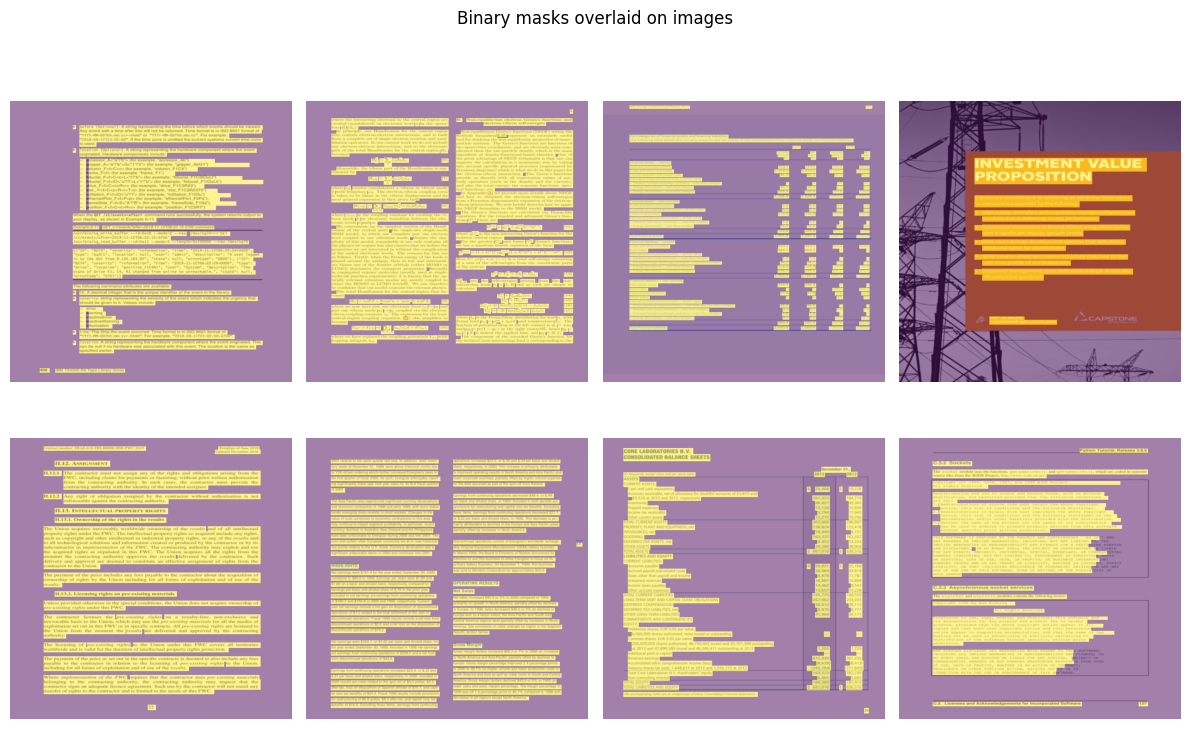

In [28]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_binary_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_binary_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_binary_masks[b].permute(1, 2, 0).cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Binary masks overlaid on images")
plt.tight_layout()
plt.show()

#### 1.1.2 Load `semantic-layout` masks and inspect a single batch

In [29]:
semantic_train_dl, semantic_val_dl, semantic_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="semantic-layout",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    transform=None,
)

In [30]:
sample_batch_semantic = next(iter(semantic_train_dl))

batch_semantic_imgs  : torch.Tensor = sample_batch_semantic[0]
batch_semantic_masks : torch.Tensor = sample_batch_semantic[1]
batch_semantic_meta  : dict         = sample_batch_semantic[2]

print(f"Semantic images shape : {batch_semantic_imgs.shape}")
print(f"Semantic masks  shape : {batch_semantic_masks.shape}  "
      f"max={batch_semantic_masks.max()}  min={batch_semantic_masks.min()}  "
      f"dtype={batch_semantic_masks.dtype}")

Semantic images shape : torch.Size([8, 3, 512, 512])
Semantic masks  shape : torch.Size([8, 512, 512])  max=10  min=0  dtype=torch.int64


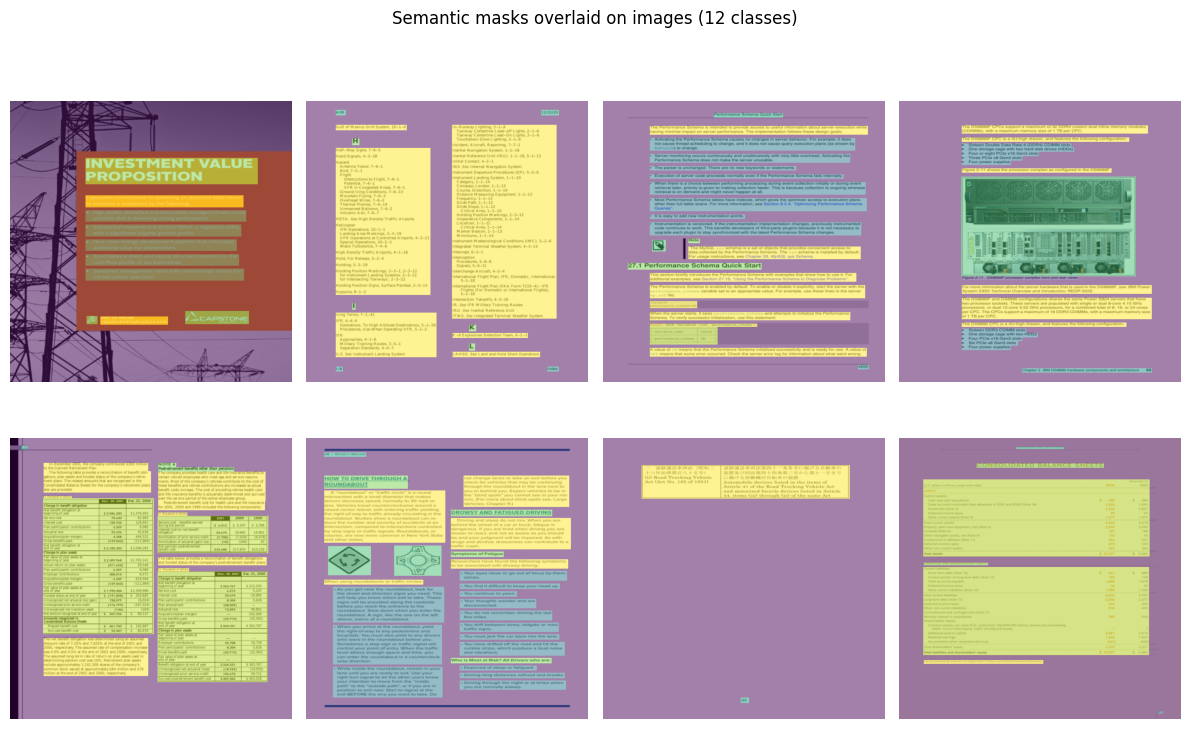

In [31]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_semantic_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_semantic_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_semantic_masks[b].cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Semantic masks overlaid on images (12 classes)")
plt.tight_layout()
plt.show()

### 1.2. Instantiate `LinkNet` model for `binary text segmentation`

In [32]:
from src.models import LinknetModel

In [33]:
# Let's instantiate a binary_text_model
binary_text_model = LinknetModel(Cin=3, N = 1)

In [34]:
from torchinfo import summary
summary(model = binary_text_model,
        input_size=(1, 3, 512, 512), # (batch_size, num_channels, height, width) -> (B * 64 * 256 * 256)
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
LinknetModel (LinknetModel)                   [1, 3, 512, 512]     [1, 1, 512, 512]     --                   True
├─LinknetStem (stem)                          [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    └─Sequential (linknet_stem)              [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    │    └─Conv2d (0)                        [1, 3, 512, 512]     [1, 64, 256, 256]    9,408                True
│    │    └─BatchNorm2d (1)                   [1, 64, 256, 256]    [1, 64, 256, 256]    128                  True
│    │    └─ReLU (2)                          [1, 64, 256, 256]    [1, 64, 256, 256]    --                   --
│    │    └─MaxPool2d (3)                     [1, 64, 256, 256]    [1, 64, 128, 128]    --                   --
├─LinknetEncoderBlock (encoder_block_1)       [1, 64, 128, 128]    [1, 64, 64, 64]     

## 2. Get different instances of `LinkNet` models for semantic-pdf-layout segmentation

In [35]:
from src.utils import MetadataRetriever

# Let's get the metadata supercategories
metadata_retriever = MetadataRetriever(
    data_path=data_path,
    dataset_name=subset_dataname,
    split_analyze="test")

supercategories_classes = metadata_retriever.get_metadata_supercategories()
CLASSES = len(supercategories_classes) + 1 # Adding one for the background
CLASSES

12

In [36]:
# Let's instantiate a binary_text_model
segmentation_pdf_model = LinknetModel(Cin=3, N = CLASSES)

In [37]:
from torchinfo import summary
summary(model = segmentation_pdf_model,
        input_size=(1, 3, 512, 512), # (batch_size, num_channels, height, width) -> (B * 64 * 256 * 256)
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
LinknetModel (LinknetModel)                   [1, 3, 512, 512]     [1, 12, 512, 512]    --                   True
├─LinknetStem (stem)                          [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    └─Sequential (linknet_stem)              [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    │    └─Conv2d (0)                        [1, 3, 512, 512]     [1, 64, 256, 256]    9,408                True
│    │    └─BatchNorm2d (1)                   [1, 64, 256, 256]    [1, 64, 256, 256]    128                  True
│    │    └─ReLU (2)                          [1, 64, 256, 256]    [1, 64, 256, 256]    --                   --
│    │    └─MaxPool2d (3)                     [1, 64, 256, 256]    [1, 64, 128, 128]    --                   --
├─LinknetEncoderBlock (encoder_block_1)       [1, 64, 128, 128]    [1, 64, 64, 64]     

## 3. Import from `src.utils ` all necessary functions to obtain pixel-region metrics

In [38]:
from src.utils import get_binary_metrics, get_semantic_metrics, get_region_metrics

## 4. Let's create the `train_step()` function
This will be key to do! be careful with little details.

In [39]:
'''
This trains a PyTorch linknet semantic segmentation model,
in both the binary and multiclass segmentation settings
code.
'''
import torch
from typing import Tuple, Dict, List, Union
from tqdm import tqdm
from collections import defaultdict

def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device,
               binary:bool = True,
               ignore_background:bool = True,
               reduction:str = "macro") -> Tuple[float, float]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    binary: Boolean that determines wether is binary segmentation, or not.
    ignore_background: Boolean falg that determines in semantic segmentation, to ignore
    background class 0 or not.
    reduction: string that either is macro or micro, for semantic kind of pixel metrics
    calculation.

    Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)

    """

    assert reduction in ["macro", "micro"], "Reduction must be either 'macro' or 'micro'."

    model.train()

    train_loss = 0.0
    total_metrics: Dict[str, float] = defaultdict(float)
    num_batches = 0

    for batch, (X_imgs, X_masks, X_metadata) in enumerate(dataloader):

        # Move data to device
        X_imgs = X_imgs.to(device)
        X_masks = X_masks.to(device)

        # Forward pass
        X_logits = model(X_imgs)

        # Compute loss
        loss = loss_fn(X_logits, X_masks)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metric computation (no gradient tracking)
        with torch.no_grad():

            if binary:
                pixel_metrics = get_binary_metrics(X_logits, X_masks)
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=True
                )
            else:
                pixel_metrics = get_semantic_metrics(
                    logits=X_logits,
                    targets=X_masks,
                    num_classes=X_logits.shape[1],
                    ignore_background=ignore_background,
                    reduction=reduction
                )
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=False
                )

            # Accumulate pixel-level metrics
            for k, v in pixel_metrics.items():
                total_metrics[k] += float(v)

            # Accumulate region-level metrics (averaged per batch)
            for k, v in region_metrics.items():
                total_metrics[k] += float(v.mean())

        num_batches += 1

    # Compute averages
    avg_loss = train_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}

    return avg_loss, avg_metrics